# EDA for ICBHI 2017

This notebook follows Task 5 from `tasks.md` and produces the required class counts, plots, and patient-level summaries.

In [2]:
from pathlib import Path
import os

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import IPython.display as ipd

plt.style.use("seaborn-v0_8-whitegrid")
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists() and (PROJECT_ROOT.parent / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
LOG_DIR = PROJECT_ROOT / "logs"
os.makedirs(LOG_DIR, exist_ok=True)

LABEL_NAMES = ["normal", "crackle", "wheeze", "both"]
DEVICE_NAMES = ["AKGC417L", "LittC2SE", "Litt3200", "Meditron"]
DEVICE_MAP = {name: idx for idx, name in enumerate(DEVICE_NAMES)}


def label_from_flags(crackle: float, wheeze: float) -> int:
    if crackle == 0 and wheeze == 0:
        return 0
    if crackle == 1 and wheeze == 0:
        return 1
    if crackle == 0 and wheeze == 1:
        return 2
    return 3


def device_from_name(stem: str) -> str:
    device = stem.split("_")[-1]
    return device if device in DEVICE_MAP else "Unknown"


records = []
for wav_path in sorted(RAW_DIR.glob("*.wav")):
    txt_path = wav_path.with_suffix(".txt")
    if not txt_path.exists():
        continue
    patient_id = wav_path.stem.split("_")[0]
    device = device_from_name(wav_path.stem)
    with txt_path.open("r", encoding="utf-8", errors="ignore") as handle:
        for cycle_idx, line in enumerate(handle):
            parts = line.split()
            if len(parts) != 4:
                continue
            try:
                start, end, crackle, wheeze = map(float, parts)
            except ValueError:
                continue
            label = label_from_flags(crackle, wheeze)
            records.append(
                {
                    "patient_id": patient_id,
                    "recording": wav_path.stem,
                    "wav_path": str(wav_path),
                    "txt_path": str(txt_path),
                    "cycle_idx": cycle_idx,
                    "start": start,
                    "end": end,
                    "label": label,
                    "label_name": LABEL_NAMES[label],
                    "device": device,
                    "duration": end - start,
                }
            )

cycles_df = pd.DataFrame(records)
counts = cycles_df["label"].value_counts().reindex(range(4), fill_value=0)
print(f"normal:  {counts[0]}")
print(f"crackle: {counts[1]}")
print(f"wheeze:   {counts[2]}")
print(f"both:     {counts[3]}")
print(f"total:   {len(cycles_df)}")

normal:  3642
crackle: 1864
wheeze:   886
both:     506
total:   6898


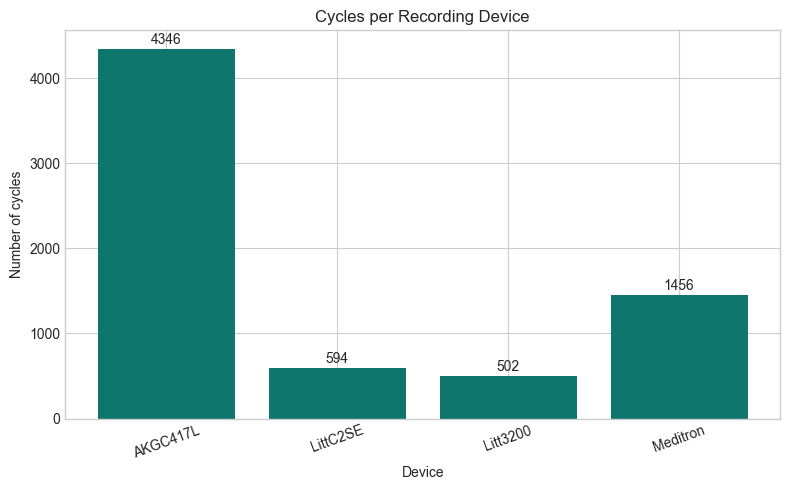

In [6]:
device_counts = cycles_df.groupby("device").size().reindex(DEVICE_NAMES, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(device_counts.index, device_counts.values, color="#0f766e")
ax.set_title("Cycles per Recording Device")
ax.set_xlabel("Device")
ax.set_ylabel("Number of cycles")
ax.tick_params(axis="x", rotation=20)
for idx, value in enumerate(device_counts.values):
    ax.text(idx, value + 20, str(int(value)), ha="center", va="bottom")
fig.tight_layout()
plt.show()

In [9]:
patient_counts = cycles_df.groupby("patient_id").size()
print(f"Unique patients: {patient_counts.index.nunique()}")
print(f"Cycles per patient - min: {patient_counts.min()}")
print(f"Cycles per patient - max: {patient_counts.max()}")
print(f"Cycles per patient - mean: {patient_counts.mean():.2f}")
print(f"Total patients: {len(patient_counts)}")

Unique patients: 126
Cycles per patient - min: 4
Cycles per patient - max: 507
Cycles per patient - mean: 54.75
Total patients: 126


C:\Temp\ipykernel_18712\2667272515.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


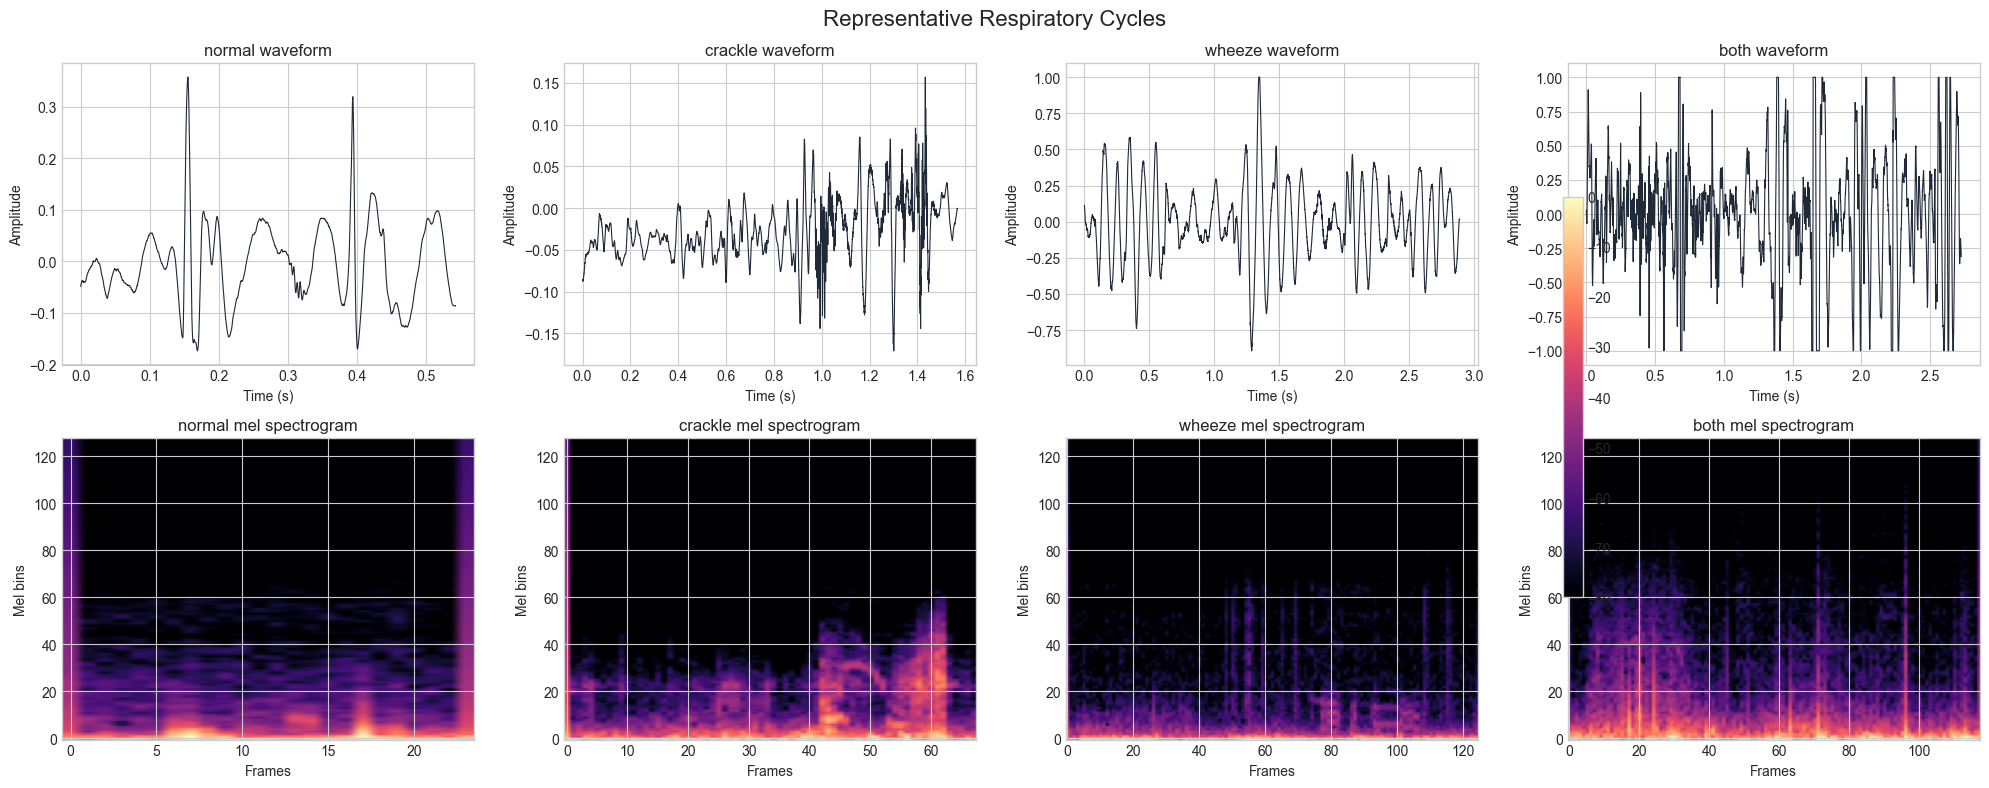

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for col, label_name in enumerate(LABEL_NAMES):
    example_row = cycles_df[cycles_df["label_name"] == label_name].iloc[0]
    cycle, sr = load_cycle_audio(example_row)
    time_axis = np.linspace(0, len(cycle) / sr, num=len(cycle))
    mel = librosa.feature.melspectrogram(y=cycle, sr=sr, n_mels=128, n_fft=1024, hop_length=512, fmax=8000)
    log_mel = librosa.power_to_db(mel, ref=np.max)

    axes[0, col].plot(time_axis, cycle, color="#1f2937", linewidth=0.8)
    axes[0, col].set_title(f"{label_name} waveform")
    axes[0, col].set_xlabel("Time (s)")
    axes[0, col].set_ylabel("Amplitude")

    img = axes[1, col].imshow(log_mel, aspect="auto", origin="lower", cmap="magma")
    axes[1, col].set_title(f"{label_name} mel spectrogram")
    axes[1, col].set_xlabel("Frames")
    axes[1, col].set_ylabel("Mel bins")

fig.colorbar(img, ax=axes.ravel().tolist(), shrink=0.65, location="right")
fig.suptitle("Representative Respiratory Cycles", fontsize=16)
fig.tight_layout()
fig.savefig("logs/sample_spectrograms.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
def load_cycle_audio(row):
    audio, sr = librosa.load(row["wav_path"], sr=22050, mono=True)
    start_idx = int(row["start"] * sr)
    end_idx = int(row["end"] * sr)
    cycle = audio[start_idx:end_idx]
    return cycle, sr

for label_idx, label_name in enumerate(LABEL_NAMES):
    example_row = cycles_df[cycles_df["label"] == label_idx].iloc[0]
    cycle, sr = load_cycle_audio(example_row)
    print(f"{label_name}: {example_row['recording']} cycle {int(example_row['cycle_idx'])}")
    display(ipd.Audio(cycle, rate=sr))

d:\younes\respiratory-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


normal: 101_1b1_Al_sc_Meditron cycle 0


crackle: 104_1b1_Ll_sc_Litt3200 cycle 4


wheeze: 103_2b2_Ar_mc_LittC2SE cycle 0


both: 107_2b3_Ar_mc_AKGC417L cycle 1


Min duration: 0.200 s
Max duration: 16.163 s
Mean duration: 2.701 s
Median duration: 2.537 s


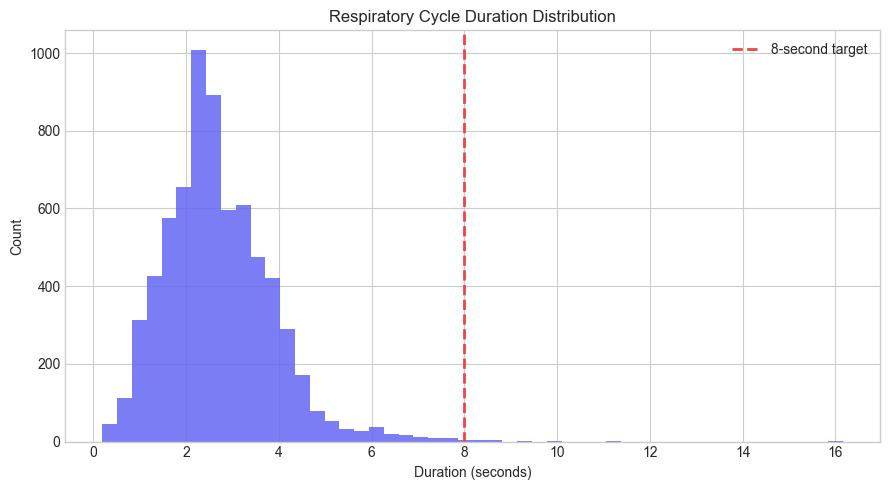

In [5]:
duration_min = cycles_df["duration"].min()
duration_max = cycles_df["duration"].max()
duration_mean = cycles_df["duration"].mean()
duration_median = cycles_df["duration"].median()
print(f"Min duration: {duration_min:.3f} s")
print(f"Max duration: {duration_max:.3f} s")
print(f"Mean duration: {duration_mean:.3f} s")
print(f"Median duration: {duration_median:.3f} s")
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cycles_df["duration"], bins=50, color="#6366f1", alpha=0.85)
ax.axvline(8.0, color="#ef4444", linestyle="--", linewidth=2, label="8-second target")
ax.set_title("Respiratory Cycle Duration Distribution")
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()

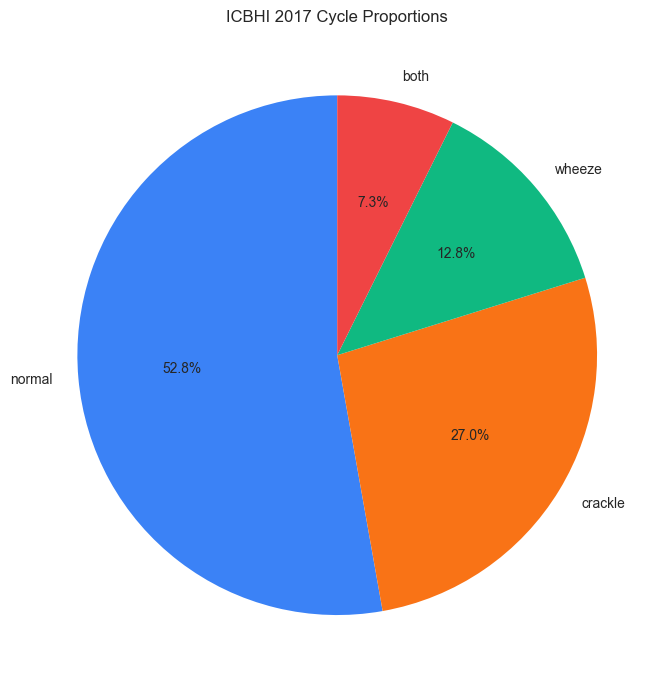

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(class_counts.values, labels=LABEL_NAMES, autopct="%1.1f%%", startangle=90, colors=["#3b82f6", "#f97316", "#10b981", "#ef4444"])
ax.set_title("ICBHI 2017 Cycle Proportions")
fig.tight_layout()
plt.show()

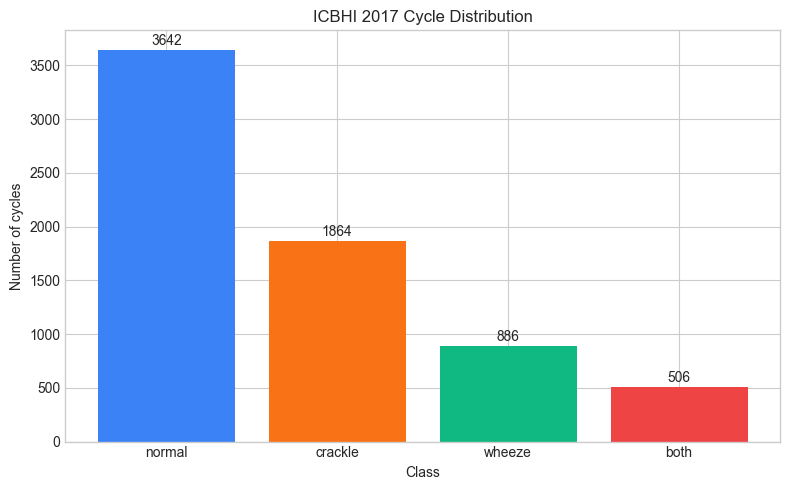

In [3]:
class_counts = cycles_df["label"].value_counts().reindex(range(4), fill_value=0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(LABEL_NAMES, class_counts.values, color=["#3b82f6", "#f97316", "#10b981", "#ef4444"])
ax.set_title("ICBHI 2017 Cycle Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of cycles")
for idx, value in enumerate(class_counts.values):
    ax.text(idx, value + 20, str(int(value)), ha="center", va="bottom")
fig.tight_layout()
fig.savefig("logs/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()